# Avaliação de Modelos

Quais melhores modelos para testar as metricas
- Metricas a serem validadas:
    - F1 Score
    - ROC-AUC
- Modelos a serem testados:
    - Regressão
    - Decision Tree
    - randomforest
    - XGBoost

In [5]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,recall_score, precision_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
from src.data.load_data import import_dataset
from src.config import features, features_cat, features_num, target
from src.preprocess import churn_mapped, create_preprocessor, train_test, total_charges



In [6]:
df = import_dataset(r"..\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df["TotalCharges"] = total_charges(df)

TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [ ]:

X = df[features]
y = churn_mapped(df, target)


X_train, X_test, y_train, y_test = train_test(X,y)


In [13]:
preprocessor_lr = create_preprocessor(features_num, features_cat)

In [14]:
pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('model', LogisticRegression(class_weight='balanced',random_state=42, max_iter=1000))
])
pipeline.fit(X_train, y_train)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1]

Accuracy

In [ ]:
print('Accuracy: ',accuracy_score(y_test, y_pred))
print('Recall: ', recall_score(y_test, y_pred))
print('Precision: ',precision_score(y_test, y_pred))
print('F1-Score: ', f1_score(y_test, y_pred))
print('ROC-AUC: ', roc_auc_score(y_test, y_proba))

Accuracy:  0.7374024130589071
Recall:  0.7834224598930482
Precision:  0.5034364261168385
F1-Score:  0.6129707112970711
ROC-AUC:  0.8414063912785139


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



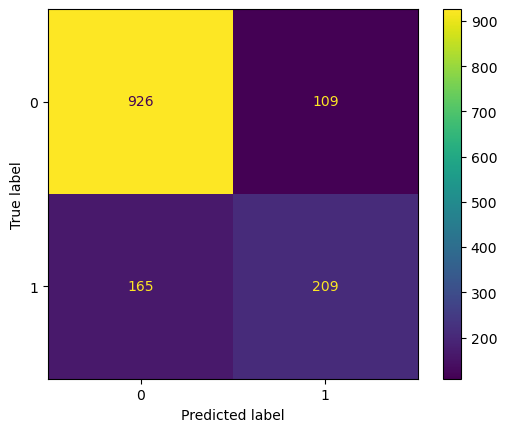

In [ ]:
print(ConfusionMatrixDisplay.from_predictions(y_test, y_pred))